## **Project: Medical Insurance Cost Prediction**
---

### **Load Data**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")
df.shape

(1338, 7)

### **Preprocessing**
---

In [2]:
df = pd.get_dummies(df).astype(int)
df.head()

,age,bmi,children,expenses,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,1,0,0,1,0,0,0,1
1,18,33,1,1725,0,1,1,0,0,0,1,0
2,28,33,3,4449,0,1,1,0,0,0,1,0
3,33,22,0,21984,0,1,1,0,0,1,0,0
4,32,28,0,3866,0,1,1,0,0,1,0,0


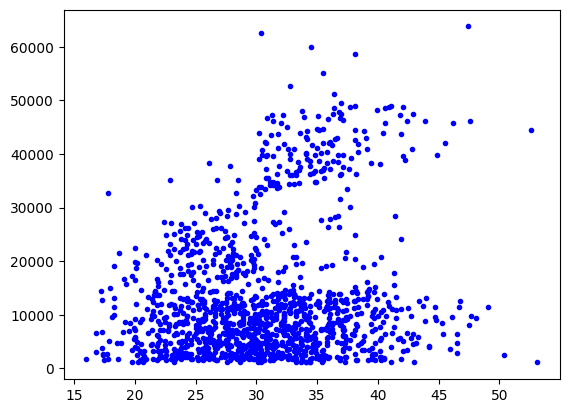

In [14]:
plt.plot(df["bmi"],df["expenses"],"b.")
plt.show()


## **Features & Target**
---

In [15]:
X = df[["age","bmi"]]
y = df["expenses"]

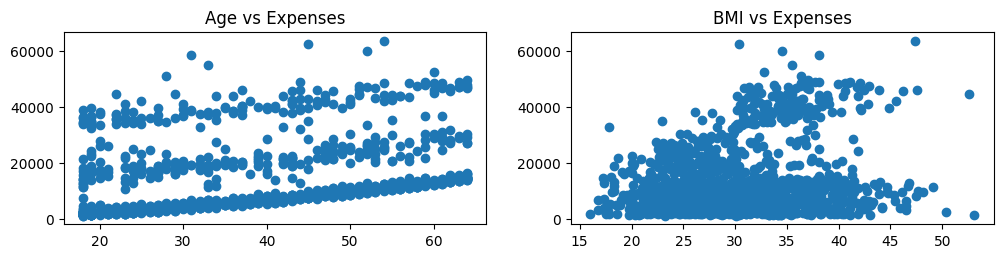

In [16]:
import matplotlib.pyplot as plt

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,2.5))
ax1.scatter(df["age"],df["expenses"])
ax1.set_title("Age vs Expenses")

ax2.scatter(df["bmi"],df["expenses"])
ax2.set_title("BMI vs Expenses")

plt.show()

## **Train / Test Split**
---

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## **Linear Regression** (Baseline)
---

In [18]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

lr_y_pred = lr_model.predict(X_test)

## **Poynomial Regression**
---

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train[["age","bmi"]])
X_test_poly = poly.transform(X_test[["age","bmi"]])

poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train)

poly_y_pred = poly_model.predict(X_test_poly)

## **Evaluation**
---

In [22]:
from sklearn.metrics import mean_squared_error,r2_score

print("Linear MSE: ",mean_squared_error(y_test,lr_y_pred))
print("Polynomial MSE: ",mean_squared_error(y_test,poly_y_pred))

print("Linear R2: ",r2_score(y_test,lr_y_pred))
print("Polynomial R2: ",r2_score(y_test,poly_y_pred))

Linear MSE:  131426373.13608588
Polynomial MSE:  132661457.32393108
Linear R2:  0.15344640834762258
Polynomial R2:  0.14549088975371927
